In [8]:
import pandas as pd
from pathlib import Path

In [9]:
# Set the data folder path
data_folder = Path('./data')

# Read all data files (adjust file extensions as needed)
file_extensions = ['*.csv', '*.xlsx', '*.parquet']
all_files = []

for ext in file_extensions:
    all_files.extend(data_folder.glob(ext))

# Combine all data files
dfs = []
for file in all_files:
    try:
        if file.suffix == '.csv':
            df = pd.read_csv(file)
        dfs.append(df)
        print(f"Loaded: {file.name}")
    except Exception as e:
        print(f"Error loading {file.name}: {e}")

# Combine all dataframes
if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # Extract year from Month field (format: 'YYYY-MM')
    combined_df['Year'] = combined_df['month'].str[:4]
    
    # Count records by year
    year_counts = combined_df['Year'].value_counts().sort_index()
    
    print("\n--- Records by Year ---")
    for year, count in year_counts.items():
        print(f"{year}: {count} records")
else:
    print("No data files found in the folder")

Loaded: ResaleFlatPricesBasedonApprovalDate2000Feb2012.csv
Loaded: ResaleFlatPricesBasedonRegistrationDateFromJan2015toDec2016.csv
Loaded: ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv
Loaded: ResaleFlatPricesBasedonRegistrationDateFromMar2012toDec2014.csv
Loaded: ResaleFlatPricesBasedonApprovalDate19901999.csv

--- Records by Year ---
1990: 12505 records
1991: 12855 records
1992: 14503 records
1993: 18116 records
1994: 26373 records
1995: 27289 records
1996: 34919 records
1997: 31759 records
1998: 51095 records
1999: 57782 records
2000: 34862 records
2001: 38055 records
2002: 36098 records
2003: 29003 records
2004: 29112 records
2005: 30045 records
2006: 27427 records
2007: 26982 records
2008: 27262 records
2009: 30482 records
2010: 34854 records
2011: 22281 records
2012: 23198 records
2013: 16097 records
2014: 16096 records
2015: 17780 records
2016: 19373 records
2017: 20509 records
2018: 21561 records
2019: 22186 records
2020: 23333 records
2021: 29087 records
2022: 

In [10]:
by_year = (
    combined_df
    .dropna(subset=['Year', 'resale_price'])
    .groupby('Year')['resale_price']
    .agg(min_price='min', max_price='max')
    .sort_index()
)

for year, row in by_year.iterrows():
    print(f"{year}: min = {row['min_price']:.2f}, max = {row['max_price']:.2f}")

1990: min = 5000.00, max = 267000.00
1991: min = 5700.00, max = 300000.00
1992: min = 7000.00, max = 335000.00
1993: min = 7500.00, max = 460000.00
1994: min = 10500.00, max = 550000.00
1995: min = 25000.00, max = 680000.00
1996: min = 32000.00, max = 900000.00
1997: min = 45000.00, max = 840000.00
1998: min = 35000.00, max = 792500.00
1999: min = 31000.00, max = 731000.00
2000: min = 36000.00, max = 728000.00
2001: min = 28000.00, max = 740000.00
2002: min = 29000.00, max = 700000.00
2003: min = 35000.00, max = 670000.00
2004: min = 55000.00, max = 670000.00
2005: min = 40000.00, max = 635000.00
2006: min = 65000.00, max = 600000.00
2007: min = 73000.00, max = 780000.00
2008: min = 90000.00, max = 890000.00
2009: min = 127000.00, max = 818000.00
2010: min = 140000.00, max = 900000.00
2011: min = 190000.00, max = 903000.00
2012: min = 209000.00, max = 1010000.00
2013: min = 208000.00, max = 1050000.00
2014: min = 195000.00, max = 1088888.00
2015: min = 195000.00, max = 1088000.00
2016:

I'll add the plotting step to the todo list and mark it completed.

Created 4 todos

Progress: added plotting step. Paste this after your `by_year` calculation (it uses matplotlib):



ValueError: The number of FixedLocator locations (37), usually from a call to set_ticks, does not match the number of labels (17).

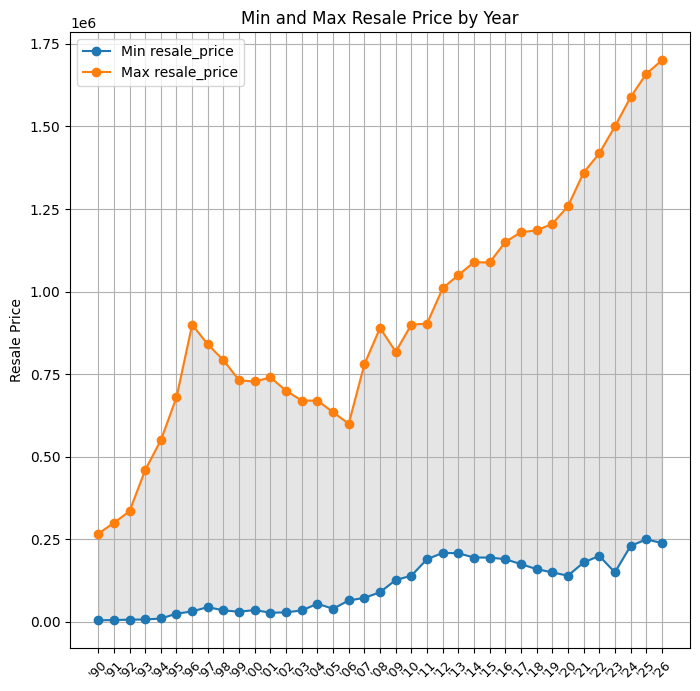

In [33]:
import matplotlib.pyplot as plt

# ensure numeric x-axis
try:
    years = by_year.index.astype(int)
except Exception:
    years = range(len(by_year))
    # use labels if non-numeric
    x_labels = by_year.index.tolist()

mins = by_year['min_price'].values
maxs = by_year['max_price'].values

plt.figure(figsize=(8,8))
plt.plot(years, mins, marker='o', label='Min resale_price')
plt.plot(years, maxs, marker='o', label='Max resale_price')
plt.fill_between(years, mins, maxs, color='gray', alpha=0.2)
short_years = [f"'{str(y)[-2:]}" for y in years]
plt.xticks(years, short_years, rotation=45, fontsize=9)
plt.ylabel('Resale Price')
plt.title('Min and Max Resale Price by Year')
plt.grid(True)
plt.legend()
if 'x_labels' in locals():
    plt.xticks(years, x_labels, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
threshold = 1000000
# ensure resale_price numeric and Year exists
df = combined_df.dropna(subset=['Year']).copy()
# total count per year 
total_counts = df.groupby('Year')['resale_price'].count()
# count above threshold per year
above_counts = df[df['resale_price'] > threshold].groupby('Year')['resale_price'].count()
# combine into a dataframe and compute percentage
result = pd.DataFrame({'total': total_counts, 'above_1M': above_counts}).fillna(0)
result['pct_above_1M'] = result['above_1M'] / result['total'] * 100
result = result.sort_index()
# Print a table then per-year readable lines
print('Summary (counts and % above 1,000,000) by Year:\n')
print(result.to_string())
print('\nReadable per-year:')
for year, row in result.iterrows():
    print(f"{year}: {int(row['above_1M'])} above 1,000,000 ({row['pct_above_1M']:.2f}%) out of {int(row['total'])} total")

Summary (counts and % above 1,000,000) by Year:

      total  above_1M  pct_above_1M
Year                               
1990  12505       0.0      0.000000
1991  12855       0.0      0.000000
1992  14503       0.0      0.000000
1993  18116       0.0      0.000000
1994  26373       0.0      0.000000
1995  27289       0.0      0.000000
1996  34919       0.0      0.000000
1997  31759       0.0      0.000000
1998  51095       0.0      0.000000
1999  57782       0.0      0.000000
2000  34862       0.0      0.000000
2001  38055       0.0      0.000000
2002  36098       0.0      0.000000
2003  29003       0.0      0.000000
2004  29112       0.0      0.000000
2005  30045       0.0      0.000000
2006  27427       0.0      0.000000
2007  26982       0.0      0.000000
2008  27262       0.0      0.000000
2009  30482       0.0      0.000000
2010  34854       0.0      0.000000
2011  22281       0.0      0.000000
2012  23198       1.0      0.004311
2013  16097       2.0      0.012425
2014  16096    

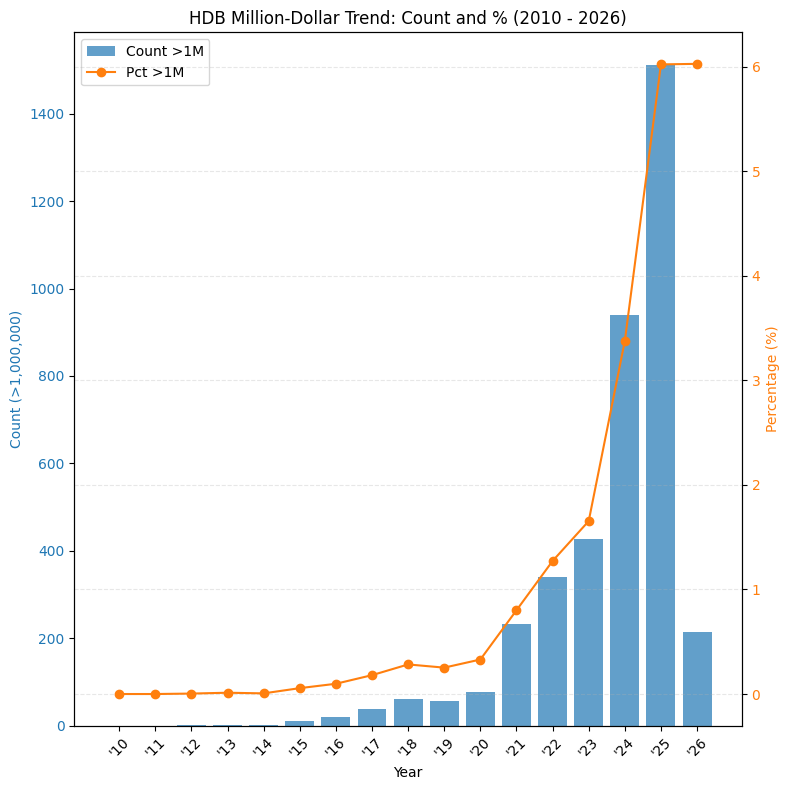

In [34]:
result_filtered = result[result.index.astype(int) >= 2010]

years = result_filtered.index.tolist()

try:
    x = [int(y) for y in years]
    # Create the 2-digit labels (e.g., '10, '11, ... '26)
    x_labels = [f"'{str(y)[-2:]}" for y in x]
except Exception:
    x = list(range(len(years)))
    x_labels = [str(y)[-2:] for y in years]

counts = result_filtered['above_1M'].astype(int).values
pct = result_filtered['pct_above_1M'].values

fig, ax1 = plt.subplots(figsize=(8,8))

# Plotting the Bars
ax1.bar(x, counts, color='C0', alpha=0.7, label='Count >1M')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count (>1,000,000)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')

# Setting the 2-digit labels on the X-axis
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=45)

# Secondary axis for Percentage
ax2 = ax1.twinx()
ax2.plot(x, pct, color='C1', marker='o', label='Pct >1M')
ax2.set_ylabel('Percentage (%)', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')

plt.title('HDB Million-Dollar Trend: Count and % (2010 - 2026)')

# Combining legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()